文件已生成: CMJ_EMG_Simulated.csv
   Time (s)  Gluteus Medius (GMed)  Vastus Medialis (VM)  Biceps Femoris (BF)  \
0  0.000000               0.009934              0.011412            -0.008475   
1  0.001000              -0.002765              0.019364            -0.009068   
2  0.002001               0.012954             -0.006626            -0.035913   
3  0.003001               0.030461             -0.012245            -0.006602   
4  0.004002              -0.004683             -0.021703             0.014657   

   Tibialis Anterior (TA)  Gastrocnemius Medialis (GM)  
0                0.035269                    -0.013570  
1                0.002491                    -0.006110  
2                0.015410                    -0.011948  
3                0.002043                     0.002208  
4               -0.013660                     0.023944  


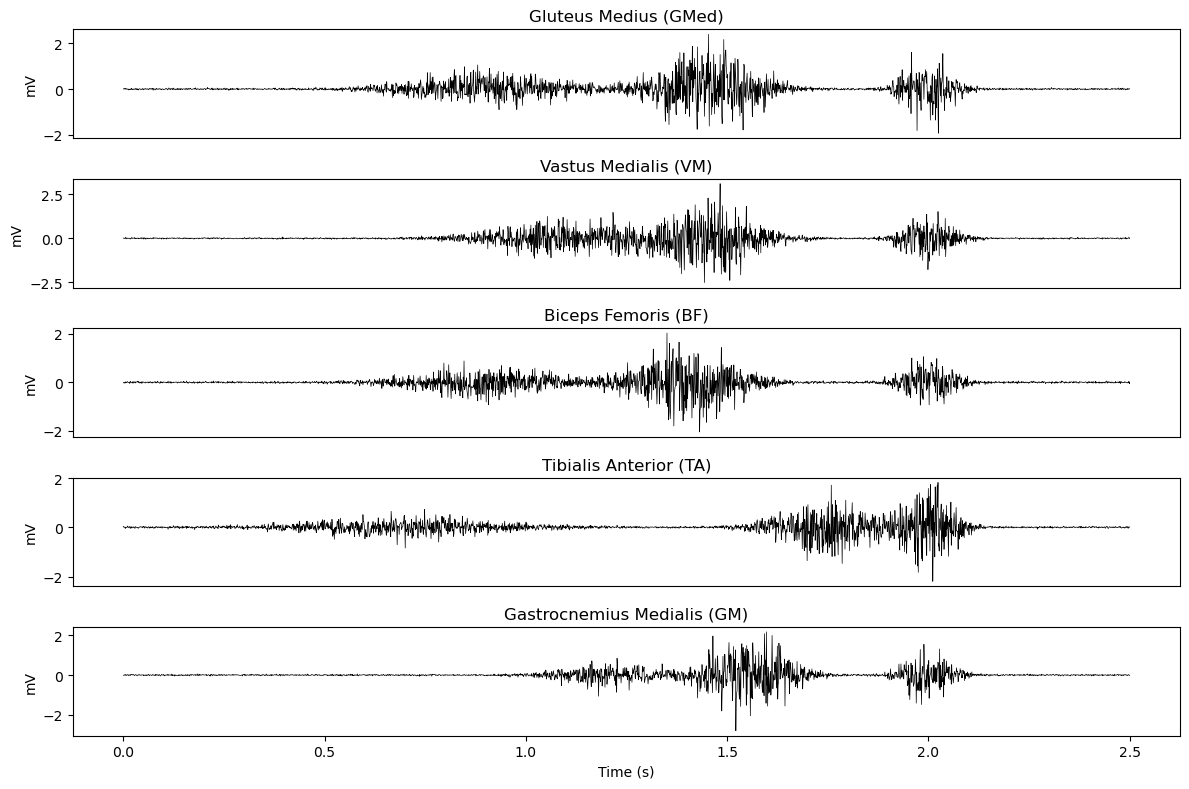

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 设置随机种子和参数
np.random.seed(42)
fs = 1000  # 采样率 1000Hz
duration = 2.5  # 时长 2.5秒
t = np.linspace(0, duration, int(fs * duration))
n_samples = len(t)

# 2. 定义肌肉激活包络函数 (模拟肌肉发力模式)
def create_burst(t, center, width, amplitude):
    return amplitude * np.exp(-((t - center)**2) / (2 * width**2))

# 3. 定义各肌肉的激活时序 (基于 CMJ 动作生物力学)
# 臀中肌: 离心期稳定骨盆 + 向心期伸髋 + 落地缓冲
act_GMed = (create_burst(t, 0.9, 0.15, 0.4) + create_burst(t, 1.45, 0.1, 0.9) + create_burst(t, 2.0, 0.05, 0.7))

# 股内侧肌: 离心制动 + 向心爆发(最大) + 落地缓冲
act_VM = (create_burst(t, 1.1, 0.15, 0.5) + create_burst(t, 1.45, 0.1, 1.0) + create_burst(t, 2.0, 0.05, 0.8))

# 股二头肌: 离心控制 + 伸髋协同 + 落地保护
act_BF = (create_burst(t, 0.9, 0.15, 0.3) + create_burst(t, 1.4, 0.1, 0.8) + create_burst(t, 2.0, 0.05, 0.5))

# 腓肠肌内侧: 离心稳定 + 蹬地爆发(晚于大腿) + 落地
act_GM = (create_burst(t, 1.2, 0.1, 0.3) + create_burst(t, 1.55, 0.08, 1.0) + create_burst(t, 2.0, 0.05, 0.6))

# 胫骨前肌: 腾空期背屈(为落地做准备) + 落地稳定 (起跳阶段相对静默)
act_TA = (create_burst(t, 0.7, 0.2, 0.2) + create_burst(t, 1.75, 0.1, 0.6) + create_burst(t, 2.0, 0.05, 0.9))

# 4. 生成原始 EMG 信号 (添加白噪声)
baseline_noise = 0.02
raw_data = {}
muscles = {
    'Gluteus Medius (GMed)': act_GMed,
    'Vastus Medialis (VM)': act_VM,
    'Biceps Femoris (BF)': act_BF,
    'Tibialis Anterior (TA)': act_TA,
    'Gastrocnemius Medialis (GM)': act_GM
}

for name, envelope in muscles.items():
    noise = np.random.normal(0, 1, n_samples) # 产生高斯白噪
    signal = noise * (envelope + baseline_noise) # 调制信号
    raw_data[name] = signal

# 5. 保存为 CSV 文件
df_emg = pd.DataFrame(raw_data)
df_emg.insert(0, 'Time (s)', t)
csv_filename = 'CMJ_EMG_Simulated.csv'
df_emg.to_csv(csv_filename, index=False)

print(f"文件已生成: {csv_filename}")
print(df_emg.head()) # 打印前几行查看

# 6. (可选) 绘制图像
plt.figure(figsize=(12, 8))
for i, (name, signal) in enumerate(raw_data.items()):
    plt.subplot(5, 1, i+1)
    plt.plot(t, signal, lw=0.5, color='black')
    plt.title(name)
    plt.ylabel('mV')
    if i < 4: plt.xticks([])
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()
